# Fast (C) vs Python n-mode integration

Compare the compiled `inspectre_c` n-mode Fourier-amplitude routines (from
`src/inspectre_lib.c`, SWIG-wrapped) against the pure-Python integration path in
`Inspectre`.

The **n-mode amplitude** of the (effective) source is the period-average

$$ A_n = \frac{1}{T_r}\int_0^{T_r} e^{\,i(m\,\Omega_\phi + n\,\Omega_r)\,t}\; S_m(t)\, dt, $$

where $S_m(t)$ is the $m$-th azimuthal mode of the source evaluated along the
orbit and $T_r = 2\pi/\Omega_r$ is the coordinate-time radial period.

**Python path** (existing): sample $S_m$ along an equatorial trajectory
(`source_mn_integrand_along_trajectory`), then `np.trapezoid` / `scipy.simpson` /
`CubicSpline.integrate`, divided by $T_r$.

**Fast C path**: `Inspectre.integrate_nmode_fast(...)` dispatches to a chosen
`INSPECTRE_INTEG_*` quadrature; `fft_source_nmodes_fast(...)` returns every $n$
from one FFT.

> Note: the C amplitude is already divided by $T_r$ (period-average). The raw
> Python `simpson/trapezoid` integral must be divided by $T_r$ to match.

In [1]:
import sys, os, time
# inspectre_c (the SWIG .so) lives one level up, in the inspectre project root.
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate as it
from scipy.interpolate import CubicSpline

from inspectre import Inspectre
import inspectre_c as c

print("integration modes:")
for name in sorted(n for n in dir(c) if n.startswith("INSPECTRE_INTEG_")):
    print(f"  {name:<28s} = {getattr(c, name)}")

integration modes:
  INSPECTRE_INTEG_MINO_SPLINE  = 5
  INSPECTRE_INTEG_QAG          = 0
  INSPECTRE_INTEG_QAG_MINO     = 4
  INSPECTRE_INTEG_SIMPSON      = 2
  INSPECTRE_INTEG_SPLINE       = 3
  INSPECTRE_INTEG_TIMESERIES   = 1


## 1. Orbit / field-point setup

In [2]:
a   = 0.5      # spin
p   = 10.0     # semilatus rectum
e   = 0.3      # eccentricity
x   = 1
mass = 1.0
err  = 1e-15

m, n = 2, 1               # azimuthal / radial mode
r_field, theta_field = 10.0, 1.5701   # field point (near equator)

insp = Inspectre(spin=a, semilatus_rectum=p, eccentricity=e, x=x,
                 mass=mass, err=err, mode="equatorial")

Tr = 2.0 * np.pi / insp.omega_r
print(f"omega_r={insp.omega_r:.6f}  omega_phi={insp.omega_phi:.6f}  Tr={Tr:.4f}")

omega_r=0.020048  omega_phi=0.027881  Tr=313.4029


## 2. Sanity check — per-point evaluation matches to machine precision

Before comparing integrals, confirm the C `eval_at_lambda` returns the same
puncture field and source as the Python `phi_s_m` / `source_m` at the same orbital
point. They share the underlying C kernels, so this should agree to ~1e-15.

In [3]:
insp.generate_equatorial_trajectory(num_periods=1, num_pts=2**10)
lam = insp.trajectory["lambda"][137]

# Python: set the particle at this trajectory point, evaluate
r  = insp.r_from_lambda(lam); th = insp.theta_from_lambda(lam)
ph = insp.phi_from_lambda(lam); ur = insp.four_velocity_equatorial(lam)
insp.set_particle(r, th, ph, ur)
py_phis = np.array(insp.phi_s_m(m, r_field, theta_field))
py_src  = np.array(insp.source_m(m, r_field, theta_field))

# Fast C: evaluate directly at lambda
ev = insp.eval_at_lambda_fast(m, lam, r_field, theta_field)
c_phis = np.array(ev[0]); c_src = np.array(ev[3])

print("PhiS_m   py:", py_phis, "\n         c :", c_phis,
      "\n  max|diff| =", np.max(np.abs(py_phis - c_phis)))
print("source_m py:", py_src, "\n         c :", c_src,
      "\n  max|diff| =", np.max(np.abs(py_src - c_src)))

PhiS_m   py: [-0.15748161 -0.16159061] 
         c : [-0.15748161 -0.16159061] 
  max|diff| = 0.0
source_m py: [-0.00012343 -0.00016787] 
         c : [-0.00012343 -0.00016787] 
  max|diff| = 0.0


## 3. Reference value and cross-check of the self-contained C modes

The three self-contained quadratures take no samples — they evaluate the source
internally:

- `QAG` — adaptive Gauss-Kronrod in coordinate time $t$
- `QAG_MINO` — adaptive in Mino time $\lambda$ (Jacobian-weighted)
- `MINO_SPLINE` — fixed `nSamples`-node spline quadrature in Mino time

The adaptive `QAG_MINO` (tight tolerance) is our reference "truth".

In [7]:
def c_amp(mode, nn=n, nSamples=257, epsabs=1e-12, epsrel=1e-12):
    # complex source n-mode amplitude from a C quadrature mode
    res = insp.integrate_nmode_fast(m, nn, r_field, theta_field, mode=mode,
                                    nSamples=nSamples, epsabs=epsabs, epsrel=epsrel)
    re, im = res[2]            # res = (nModePhiS, nModeDPhiS, nModesrc)
    return re + 1j*im

truth = c_amp(c.INSPECTRE_INTEG_QAG_MINO)
print(f"reference (QAG_MINO): {truth:.12e}\n")

for name in ["INSPECTRE_INTEG_QAG", "INSPECTRE_INTEG_QAG_MINO", "INSPECTRE_INTEG_MINO_SPLINE"]:
    val = c_amp(getattr(c, name), nSamples=513)
    print(f"{name:<30s} {val.real:+.12e}  relerr={abs(1-val/truth):.2e}")

reference (QAG_MINO): 1.288543225076e-04+9.797371651916e-15j

INSPECTRE_INTEG_QAG            +1.288543224943e-04  relerr=1.29e-10
INSPECTRE_INTEG_QAG_MINO       +1.288543225076e-04  relerr=0.00e+00
INSPECTRE_INTEG_MINO_SPLINE    +1.295016234599e-04  relerr=5.02e-03


## 4. Python convergence — the motivation for the fast path

The Python integrand is sampled uniformly in **Mino time** $\lambda$, then mapped
to $t$. Near the radial turning points $dt/d\lambda$ varies sharply, so
`trapezoid`/`simpson` on this non-uniform $t$ grid converge slowly — many
thousands of points are needed for high accuracy. We sweep the sample count and
plot the relative error against the C reference.

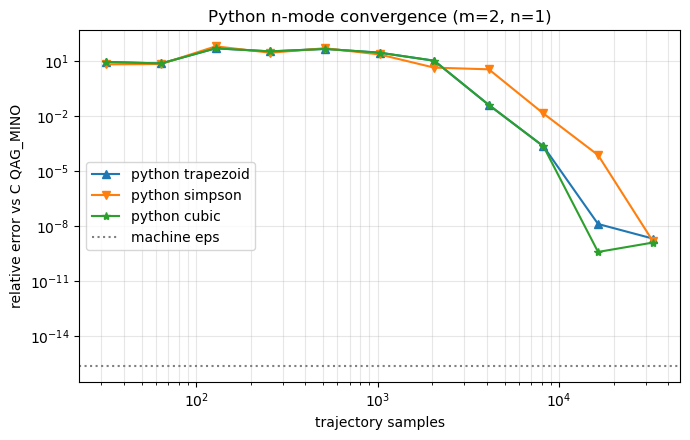

In [15]:
def py_amp(num_pts, method):
    insp.generate_equatorial_trajectory(num_periods=1, num_pts=num_pts)
    smn = insp.source_mn_integrand_along_trajectory(m, n, r_field, theta_field)
    t, re, im = smn.T
    if method == "trapezoid":
        I = np.trapezoid(re, x=t) + 1j*np.trapezoid(im, x=t)
    elif method == "simpson":
        I = it.simpson(re, x=t) + 1j*it.simpson(im, x=t)
    elif method == "cubic":
        I = (CubicSpline(t, re).integrate(t[0], t[-1])
             + 1j*CubicSpline(t, im).integrate(t[0], t[-1]))
    return I / Tr

Ns = [2**k for k in range(5, 16)]
methods = ["trapezoid", "simpson", "cubic"]
errs = {meth: [abs(1 - py_amp(N, meth)/truth) for N in Ns] for meth in methods}

fig, ax = plt.subplots(figsize=(7, 4.5))
for meth, mk in zip(methods, ["^", "v", "*"]):
    ax.loglog(Ns, errs[meth], marker=mk, label=f"python {meth}")
ax.axhline(2.2e-16, ls=":", c="grey", label="machine eps")
ax.set_xlabel("trajectory samples"); ax.set_ylabel("relative error vs C QAG_MINO")
ax.set_title(f"Python n-mode convergence (m={m}, n={n})")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Fast-path convergence — `MINO_SPLINE` node count

The self-contained `MINO_SPLINE` mode reaches reference accuracy with far fewer
source evaluations because its nodes are graded toward the turning points. Sweep
`nSamples` and overlay on the Python curve.

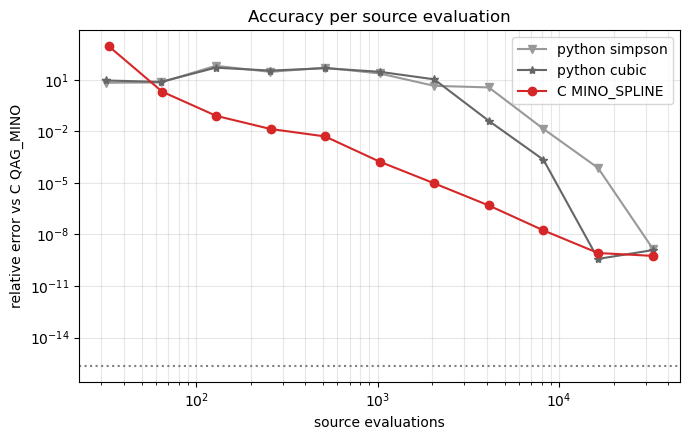

In [16]:
node_counts = np.array([2**k for k in range(5, 16)]) + 1
spline_errs = [abs(1 - c_amp(c.INSPECTRE_INTEG_MINO_SPLINE, nSamples=int(ns))/truth)
               for ns in node_counts]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(Ns, errs["simpson"], marker="v", c="0.6", label="python simpson")
ax.loglog(Ns, errs["cubic"],   marker="*", c="0.4", label="python cubic")
ax.loglog(node_counts, spline_errs, marker="o", c="C3", label="C MINO_SPLINE")
ax.axhline(2.2e-16, ls=":", c="grey")
ax.set_xlabel("source evaluations"); ax.set_ylabel("relative error vs C QAG_MINO")
ax.set_title("Accuracy per source evaluation")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Timing

Each source evaluation is expensive (the high-order Kerr coefficient files are
compiled at `-O0`), so wall time is roughly proportional to the number of
evaluations. We time a single n-mode amplitude:

- Python `simpson` at the resolution it needs for ~1e-8 accuracy,
- C `QAG_MINO` (adaptive), and
- C `MINO_SPLINE` (fixed `N_py/2` nodes).

Timings are machine-dependent; the ratio is the point.

In [19]:
def timeit(fn, repeats=3):
    timings = []
    for _ in range(repeats):
        t0 = time.perf_counter(); fn(); timings.append(time.perf_counter() - t0)
    return np.mean(timings)

# pick the python resolution that first reaches ~1e-8 with simpson (fallback: max)
target = 1e-8
N_py = next((N for N, er in zip(Ns, errs["simpson"]) if er < target), Ns[-1])
print(f"python simpson resolution for ~{target:g}: {N_py} samples")

t_py     = timeit(lambda: py_amp(N_py, "simpson"))
t_qag    = timeit(lambda: c_amp(c.INSPECTRE_INTEG_QAG_MINO))
t_spline = timeit(lambda: c_amp(c.INSPECTRE_INTEG_MINO_SPLINE, nSamples=N_py//2))

print(f"\npython simpson (N={N_py})     : {t_py*1e3:8.1f} ms")
print(f"C QAG_MINO (adaptive)         : {t_qag*1e3:8.1f} ms  ({t_py/t_qag:.1f}x)")
print(f"C MINO_SPLINE ({N_py//2} nodes)     : {t_spline*1e3:8.1f} ms  ({t_py/t_spline:.1f}x)")

python simpson resolution for ~1e-08: 32768 samples

python simpson (N=32768)     :  16280.2 ms
C QAG_MINO (adaptive)         :   6753.2 ms  (2.4x)
C MINO_SPLINE (16384 nodes)     :   7260.6 ms  (2.2x)


## 7. All-$n$ at once: `fft_source_nmodes_fast` — and its resolution limit

`fft_source_nmodes_fast` samples $g(t)=e^{i m\Omega_\phi t}S_m(t)$ on a uniform
periodic $t$-grid and returns every $n$ from one FFT — bin $k$ holds mode
$n=k$ for $k\le N/2$ else $k-N$.

The method is mathematically exact, **but** it can only sample uniformly in $t$
(that uniform grid is what makes the DFT basis $e^{i n\Omega_r t}$ orthogonal),
so unlike the adaptive/graded quadratures of §3 it **cannot concentrate nodes**.
That matters when the field point lies *inside* the orbital range
$r\in[r_{\min},r_{\max}]$: the particle makes close approaches and the effective
source develops a sharp peak (here $\max|S_m|\sim 8$, vs $\sim10^{-4}$ typical).
A fixed uniform-$t$ grid badly under-resolves that peak, so a small $N$ FFT is
far off — **not a bug, just undersampling.** It converges to the quadrature
result as $N$ grows; for field points *outside* the orbit (smooth source) even
$N=256$ is exact to ~1e-10.

In [20]:
# (a) field point INSIDE the orbital r-range (r_field=10) -> sharp source peak
rmin = insp.semilatus_rectum/(1+insp.eccentricity)
rmax = insp.semilatus_rectum/(1-insp.eccentricity)
print(f"orbital r range: [{rmin:.3f}, {rmax:.3f}];  field r={r_field} is "
      f"{'INSIDE' if rmin < r_field < rmax else 'OUTSIDE'}")

def fft_table(rf, thf, N, ns=(-2,-1,0,1,2)):
    re, im = insp.fft_source_nmodes_fast(m, rf, thf, N=N)
    amp = np.asarray(re) + 1j*np.asarray(im)
    print(f"\nfield (r={rf}, th={thf}), N={N}:")
    print("  n |     QAG        |   FFT bin      | relerr")
    for nn in ns:
        q = complex(*insp.integrate_nmode_fast(m, nn, rf, thf,
                mode=c.INSPECTRE_INTEG_QAG_MINO, epsabs=1e-12, epsrel=1e-12)[2])
        f = amp[((nn % N) + N) % N]
        print(f" {nn:+d} | {q.real:+.6e} | {f.real:+.6e} | {abs(1-f/q):.2e}")

fft_table(r_field, theta_field, N=256)      # inside, coarse -> way off
fft_table(20.0,    theta_field, N=256)      # outside, smooth -> exact
fft_table(r_field, theta_field, N=8192)     # inside, fine   -> converges

orbital r range: [7.692, 14.286];  field r=10.0 is INSIDE

field (r=10.0, th=1.5701), N=256:
  n |     QAG        |   FFT bin      | relerr
 -2 | -4.023365e-06 | -5.661756e-02 | 1.41e+04
 -1 | -4.988039e-05 | -5.566823e-02 | 1.12e+03
 +0 | +5.056334e-05 | +4.227219e-03 | 8.26e+01
 +1 | +1.288543e-04 | +5.968430e-02 | 4.62e+02
 +2 | +1.526111e-04 | +5.212414e-02 | 3.41e+02

field (r=20.0, th=1.5701), N=256:
  n |     QAG        |   FFT bin      | relerr
 -2 | +3.143220e-05 | +3.143220e-05 | 6.70e-11
 -1 | +2.966343e-05 | +2.966343e-05 | 4.08e-10
 +0 | +1.743405e-05 | +1.743405e-05 | 1.99e-09
 +1 | -1.052463e-06 | -1.052463e-06 | 2.96e-08
 +2 | +2.918069e-05 | +2.918069e-05 | 2.60e-10

field (r=10.0, th=1.5701), N=8192:
  n |     QAG        |   FFT bin      | relerr
 -2 | -4.023365e-06 | -4.150696e-06 | 3.16e-02
 -1 | -4.988039e-05 | -5.000526e-05 | 2.50e-03
 +0 | +5.056334e-05 | +5.057277e-05 | 1.86e-04
 +1 | +1.288543e-04 | +1.289881e-04 | 1.04e-03
 +2 | +1.526111e-04 | +1.527280e-04 |

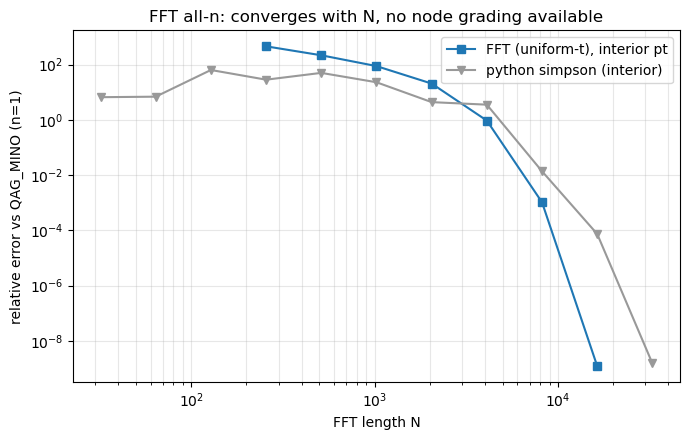

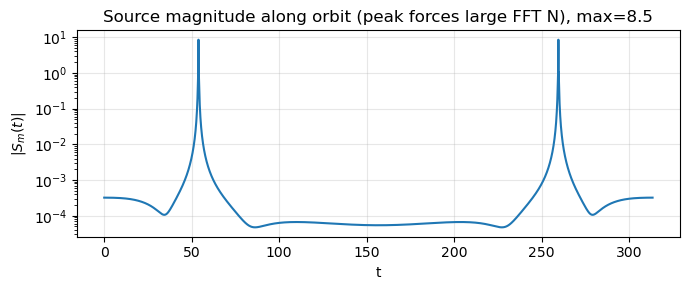

In [22]:
# FFT convergence in N at the interior (peaked) field point, mode n=1
q1 = complex(*insp.integrate_nmode_fast(m, 1, r_field, theta_field,
        mode=c.INSPECTRE_INTEG_QAG_MINO, epsabs=1e-12, epsrel=1e-12)[2])
Nfft = [256, 512, 1024, 2048, 4096, 8192, 16384]
fft_err = []
for N in Nfft:
    re, im = insp.fft_source_nmodes_fast(m, r_field, theta_field, N=N)
    amp = (np.asarray(re) + 1j*np.asarray(im))[1]
    fft_err.append(abs(1 - amp/q1))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(Nfft, fft_err, marker="s", c="C0", label="FFT (uniform-t), interior pt")
ax.loglog(Ns, errs["simpson"], marker="v", c="0.6", label="python simpson (interior)")
ax.set_xlabel("FFT length N"); ax.set_ylabel("relative error vs QAG_MINO (n=1)")
ax.set_title("FFT all-n: converges with N, no node grading available")
ax.grid(True, which="both", alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# show the underlying source peak that forces the high N
N = 8192
tg = np.linspace(0, Tr, N, endpoint=False)
src_t = np.array([abs(complex(*insp.eval_at_time_fast(
            m, t, r_field, theta_field)[3])) for t in tg])
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(tg, src_t)
ax.set_xlabel("t"); ax.set_ylabel(r"$|S_m(t)|$")
ax.set_title(f"Source magnitude along orbit (peak forces large FFT N), max={src_t.max():.2g}")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 8. Multi-mode summary table

Tabulate several $(m,n)$ at the same field point: reference (`QAG_MINO`), the
fast fixed-node `MINO_SPLINE` (513 nodes), and a converged Python `simpson`
(2^14 samples). At equal node count the fixed-node spline trails the adaptive
reference; push `nSamples` higher (see §5) for tighter agreement.

In [ ]:
insp.generate_equatorial_trajectory(num_periods=1, num_pts=2**14)

rows = []
for mm in (1, 2, 3):
    for nn in (-1, 0, 1, 2):
        ref = insp.integrate_nmode_fast(mm, nn, r_field, theta_field,
                                        mode=c.INSPECTRE_INTEG_QAG_MINO,
                                        epsabs=1e-12, epsrel=1e-12)[2]
        ref = ref[0] + 1j*ref[1]
        spl = insp.integrate_nmode_fast(mm, nn, r_field, theta_field,
                                        mode=c.INSPECTRE_INTEG_MINO_SPLINE,
                                        nSamples=512)[2]
        spl = spl[0] + 1j*spl[1]
        smn = insp.source_mn_integrand_along_trajectory(mm, nn, r_field, theta_field)
        py = (it.simpson(smn.T[1], x=smn.T[0]) + 1j*it.simpson(smn.T[2], x=smn.T[0])) / Tr
        rows.append((mm, nn, ref, abs(1-spl/ref) if ref else 0,
                     abs(1-py/ref) if ref else 0))

print(f"{'m':>2} {'n':>3} | {'QAG_MINO (ref)':>12} | {'MINO_SPLINE':>10} | {'py simpson':>10}")
print("-"*60)
for mm, nn, ref, e_spl, e_py in rows:
    print(f"{mm:>2} {nn:>3} | {ref.real:+.6e} | {e_spl:.2e}  | {e_py:.2e}")

 m   n | QAG_MINO (ref) | MINO_SPLINE | py simpson
------------------------------------------------------------
 1  -1 | -3.257565e-06 | 4.28e-02  | 8.33e-04
 1   0 | +1.612976e-04 | 6.54e-04  | 4.73e-05
 1   1 | +1.515754e-04 | 1.69e-03  | 6.54e-05
 1   2 | +1.300596e-04 | 7.86e-04  | 1.32e-05
 2  -1 | -4.988039e-05 | 4.86e-03  | 1.78e-04
 2   0 | +5.056334e-05 | 2.12e-03  | 1.32e-05
 2   1 | +1.288543e-04 | 5.02e-03  | 7.39e-05
 2   2 | +1.526111e-04 | 3.91e-03  | 5.45e-05
 3  -1 | -5.896474e-05 | 2.40e-03  | 1.74e-04
 3   0 | -6.083660e-05 | 3.96e-03  | 1.09e-04
 3   1 | +4.811218e-05 | 2.63e-02  | 8.27e-05
 3   2 | +1.632348e-04 | 1.37e-02  | 6.38e-05


In [136]:
m, n = 2, 1
ref = insp.integrate_nmode_fast(m, n, r_field, theta_field,
                                mode=c.INSPECTRE_INTEG_QAG_MINO,
                                epsabs=1e-12, epsrel=1e-12)[2]
print(ref[0] + 1j*ref[1])

N = 8192
tg = np.linspace(0, Tr, N, endpoint=False)
src_t = np.array(
    [insp.eval_at_time_fast(m, t, r_field, theta_field)[3] for t in tg]
)

# show the underlying source peak that forces the high N
omega = m * insp.omega_phi + n * insp.omega_r
integrand = np.exp(1j*omega*tg)*(src_t.T[0]+1j*src_t.T[1])
print((it.trapezoid(integrand.real,x=tg)+1j*it.trapezoid(integrand.imag,x=tg))/Tr)


N = 8192
tg = np.linspace(0, Tr/2, N, endpoint=False)
src_t = np.array(
    [insp.eval_at_time_fast(m, t, r_field, theta_field)[3] for t in tg]
)
omega = m * insp.omega_phi + n * insp.omega_r
integrand = np.exp(1j*omega*tg)*(src_t.T[0]+1j*src_t.T[1])
print((2*it.trapezoid(integrand.real, x=tg))/Tr)

(0.00012885432250761967+9.797371651915644e-15j)
(0.00012894890699722468-1.937558537357638e-11j)
0.00012886092728774307


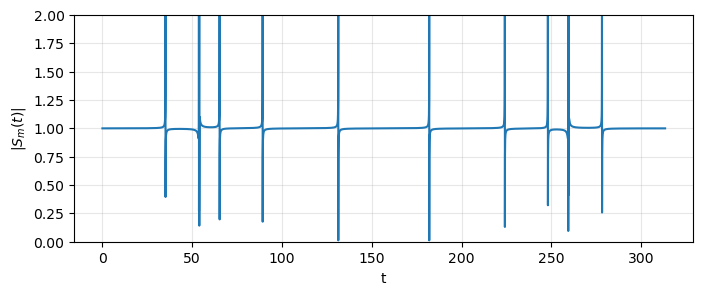

In [102]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(tg, np.abs(integrand.real[:]/(integrand.real[::-1]+1e-16)))
ax.set_xlabel("t"); ax.set_ylabel(r"$|S_m(t)|$")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.ylim(0,2); plt.show()

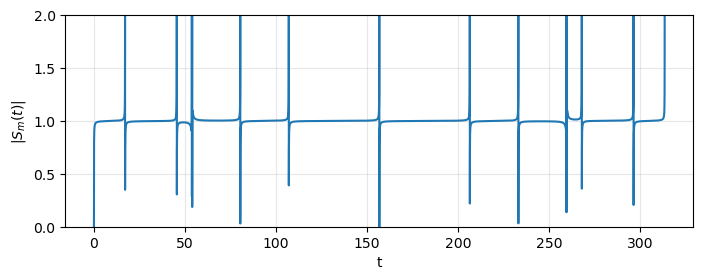

In [103]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(tg, np.abs(integrand.imag[:]/(integrand.imag[::-1]+1e-16)))
ax.set_xlabel("t"); ax.set_ylabel(r"$|S_m(t)|$")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.ylim(0,2); plt.show()